# Master BigData UCM 2024_25

## Revisión para noviembre 2025 - inc. dataset coches España 2024

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## Datos vehículos a la venta 2024 en España

Propósito:

- Facilitar la lectura del .csv que contiene los datos de este ejemplo

Origen de los datos y dónde encontrar información sobre las variables:

- Los datos están proporcionados por la European Environment Agency, en concreto esta página:
  
https://www.eea.europa.eu/en/datahub/datahubitem-view/fa8b1229-3db6-495d-b18e-9c9b3267c02b 

En esta página hay que hacer click sobre "CO2 passenger cars (elastic data viewer)" que abrirá una página nueva en la que se puede (se debe!) filtrar por alguna o varias de las variables que aparecen a la derecha.

En concreto el dataset con el que propongo trabajar (ojo, propongo! es un dataset mucho más complejo que el de UK 2016, pero es actual, ha cambiado muchísimo el mercado del automóvil) se ha obtenido simplemente filtrando por Country (escogiendo ES, el código de España) y finalmente **al final de la tabla mostrada en la página** haciendo click en "Download search results (CSV)". 

Veréis que el dataset es **enorme** y que requerirá cierto trabajo para hacer análisis equivalentes a los de UK 2016, pero ¡es un reto! Algo que yo me propongo para este curso 2025-26 y que llegado el caso -si os interesa este sector o  estos datos- os planteo también a vosotros.


### Otra (absurda) dificultad adicional de este dataset: los nombres de columnas están simplificados.

Así, en la tabla mostrada en la página sí aparecen los nombres largos (quizás larguísimos) de las columnas, pero en la descarga -lo veréis más abajo- solo aparecen siglas. Para facilitar el trabajo os pongo por aquí lo que aparece en la página, confiando que efectivamente salen en el mismo orden (!!).

- 01 ID - un código arbitrario
- 02 Country - siempre será ES -conveniente eliminar esta variable
- 03 VFN - Vehicle Family identification Number- otro código quizá significativo para algo pero creo que también evitable
- 04 Mp - Pool - conglomerado industrial de fabricantes del vehículo - lo veréis en el head
- 05 Mh - Manufacturer name (nombre comercial) - el nombre más usual pero es mejor utilizar la 12
- 06 Man - Nombre oficial del fabricante en su idioma
- 07 MMS - Ni idea (truncado en la página oficial)
- 08 Tan - Type approval number - otro código que no nos interesa
- 09 T - Type - otro código ¿de homologación? 
- 10 Va - Variant -otro código más
- 11 Ve - Version -por si había pocos códigos, otro más. Y por ninguna parte los significados
- 12 Mk - Make - el nombre oficial del fabricante del modelo -en principio debiera ser igual a Mh
- 13 Cn - Categoría 1 -truncado en página oficial
- 14 Ct - Categoría 2
- 15 r - Total new registrations
- 16 m (kg) - Mass in running order - peso del vehículo en vacío
- 17 Mt - WLTP test - el peso del vehículo tal y como ha sido probado -WLTP implica condiciones reales de uso
- 18 Enedc (g/km) - Emisiones de CO2 (1) -pero aparece vacío en muchos casos
- 19 Ewltp (g/km) - Emisiones de CO2 obtenidas en WLTP
- 20 W (mm) - Wheel base (distancia entre ejes -si no me equivoco)
- 21 At1 (mm) - Anchura eje delantero
- 22 At2 (mm) - Anchura eje trasero
- 23 Ft - Fuel type
- 24 Fm - Fuel mode (un código nuevamente)
- 25 ec (cm3) - engine capacity -en caso de motor de combustión
- 26 ep (KW) - engine power -en caso de motor eléctrico
- 27 z (Wh/km) - Electric energy consumption -en caso de motor eléctrico
- 28 IT  - Innovative technology - para variar, otro código indescifrable
- 29 Ernedc (g/km) - Emissions reduction ...  (? vacío en varios casos)
- 30 Erwltp (g/km) - Emissions reduction según test WLTP
- 31 De - deviation factor
- 32 Vf - verification factor
- 33 Status - no aparece en tabla de la página (!)
- 34 year  
- 35 Date of registration
- 36 Fuel consumption
- 37 ech - no aparece en tabla de la página (!) - puede ser tipo de equipo emisiones (todos serán euro6 pero diferentes versiones)
- 38 RLFI - RoadLoad Family I (???)
- 39 Electric range (km) - no aparece en tabla de la página (!)

In [2]:
df_sp2024 = pd.read_csv("/home/pedro/Descargas/data.csv")

In [3]:
df_sp2024.shape

(1055935, 40)

In [4]:
df_sp2024.dtypes

ID                        int64
Country                     str
VFN                         str
Mp                          str
Mh                          str
Man                         str
MMS                     float64
Tan                         str
T                           str
Va                          str
Ve                          str
Mk                          str
Cn                          str
Ct                          str
Cr                          str
r                         int64
m (kg)                  float64
Mt                      float64
Enedc (g/km)            float64
Ewltp (g/km)            float64
W (mm)                  float64
At1 (mm)                float64
At2 (mm)                float64
Ft                          str
Fm                          str
ec (cm3)                float64
ep (KW)                 float64
z (Wh/km)               float64
IT                          str
Ernedc (g/km)           float64
Erwltp (g/km)           float64
De      

In [5]:
df_sp2024.head()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,147792000,ES,IP-J12A1DNP6DA9_00-JN1-1,RENAULT-NISSAN-MITSUBISHI,NISSAN AUTOMOTIVE EUROPE,NISSAN AUTOMOTIVE EUROPE SAS,NaN,e9*2018/858*11042*08,J12,C,...,NaN,NaN,NaN,P,2024,2024-01-04,5.2,EURO 6 AP,NaN,NaN
1,147792001,ES,IP-2023_6401-W1K-1,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2018/858*00186*07,R2CGLC,865PT1,...,NaN,NaN,NaN,P,2024,2024-06-28,7.5,EURO 6 AP,NaN,NaN
2,147792002,ES,IP-050536-NLH,HYUNDAI MOTOR EUROPE,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,NaN,e5*2007/46*0090*09,AC3,B5P31,...,NaN,NaN,NaN,P,2024,2024-10-29,5.2,EURO 6 EA,NaN,NaN
3,147792003,ES,IP-MQB27ZZ_A0_121,VOLKSWAGEN,SEAT,SEAT SA,NaN,e9*2007/46*3134*45,KJ,BDUSA,...,1.9,NaN,NaN,P,2024,2024-11-28,5.2,EURO 6 EA,RL-MQ200_6F_22_004-WVW,NaN
4,147792004,ES,IP-2022_3407-W1K,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,NaN,e1*2007/46*1885*25,H1GLE,B21GT1,...,NaN,NaN,NaN,P,2024,2024-12-10,0.7,EURO 6 EA,NaN,99.0


In [6]:
pd.set_option('display.max_columns', None)
df_sp2024.describe(include = 'all')

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
count,1.055935e+06,1055935,976263,983485,1055935,1055935,0.0,1055935,1055933,1055904,1055693,1055935,1055932,1055935,1055935,1055935.0,1.055934e+06,1.027542e+06,0.0,1.055931e+06,0.0,0.0,0.0,1055935,1055935,996754.000000,1.054047e+06,118300.000000,619668,0.0,619538.000000,0.0,0.0,1055935,1055935.0,1055935,907221.000000,1055935,77453,118299.000000
unique,NaN,1,2631,11,77,75,NaN,1789,455,2039,7067,75,1899,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,5,NaN,NaN,NaN,55,NaN,NaN,NaN,NaN,1,NaN,253,NaN,12,520,NaN
top,NaN,ES,IP-HNE____MB6D542C-VR3,VOLKSWAGEN,STELLANTIS AUTO,STELLANTIS AUTO SAS,NaN,e9*2007/46*3134*44,U,A,JM5LIP,TOYOTA,SANDERO,M1,M1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,petrol,M,NaN,NaN,NaN,E9 29 37,NaN,NaN,NaN,NaN,P,NaN,2024-06-28,NaN,EURO 6 EA,RL-___CMP2MB6_5025-VR3,NaN
freq,NaN,1055935,20414,244409,96419,96421,NaN,17841,53818,33209,11930,100873,32985,1055935,1055935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,732289,512367,NaN,NaN,NaN,115261,NaN,NaN,NaN,NaN,1055935,NaN,17993,NaN,550075,3959,NaN
mean,1.478513e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.480025e+03,1.586112e+03,NaN,1.176108e+02,NaN,NaN,NaN,NaN,NaN,1479.538544,1.002457e+02,172.623381,NaN,NaN,1.474437,NaN,NaN,NaN,2024.0,NaN,5.386723,NaN,NaN,273.056628
std,3.048223e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.929518e+02,3.018932e+02,NaN,4.339419e+01,NaN,NaN,NaN,NaN,NaN,440.544789,4.284791e+01,32.383232,NaN,NaN,0.542095,NaN,NaN,NaN,0.0,NaN,1.361427,NaN,NaN,209.112928
min,1.473233e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,8.650000e+02,5.800000e+02,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,875.000000,8.000000e+00,101.000000,NaN,NaN,0.500000,NaN,NaN,NaN,2024.0,NaN,0.300000,NaN,NaN,12.000000
25%,1.475873e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.263000e+03,1.363000e+03,NaN,1.100000e+02,NaN,NaN,NaN,NaN,NaN,999.000000,7.300000e+01,153.000000,NaN,NaN,1.000000,NaN,NaN,NaN,2024.0,NaN,5.000000,NaN,NaN,69.000000
50%,1.478513e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.420000e+03,1.532000e+03,NaN,1.260000e+02,NaN,NaN,NaN,NaN,NaN,1490.000000,9.600000e+01,167.000000,NaN,NaN,1.700000,NaN,NaN,NaN,2024.0,NaN,5.500000,NaN,NaN,131.000000
75%,1.481153e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.649000e+03,1.758000e+03,NaN,1.380000e+02,NaN,NaN,NaN,NaN,NaN,1598.000000,1.100000e+02,184.000000,NaN,NaN,1.940000,NaN,NaN,NaN,2024.0,NaN,5.900000,NaN,NaN,475.000000


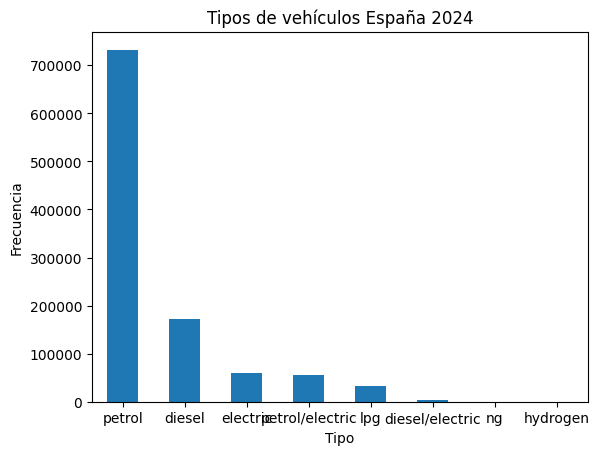

In [7]:
count_classes = df_sp2024['Ft'].value_counts(sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Tipos de vehículos España 2024")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia");

In [8]:
plt.rcParams.update({'font.size': 5})
plt.figure(figsize=(20, 12))  # tamaño muy grande

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

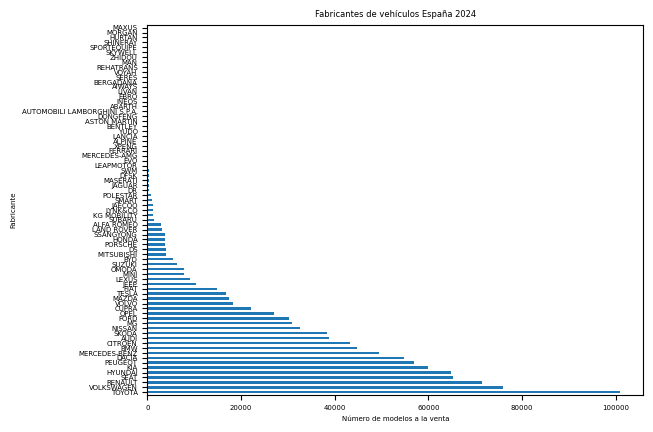

In [9]:
fig = plt.figure()
manager = plt.get_current_fig_manager()
manager.full_screen_toggle()  # activa pantalla completa

count_classes = df_sp2024.value_counts(df_sp2024['Mk'], sort = True)
count_classes.plot(kind = 'barh')
plt.title("Fabricantes de vehículos España 2024")
plt.xlabel("Número de modelos a la venta")
plt.ylabel("Fabricante")
plt.show()

# 2. Filtrado de variables y agrupación de registros

El objetivo es dejar un solo registro por modelo, agrupando y dejando solo el de última fecha. 

Hay muchas formas de hacer esto, pero yo estoy más cómodo con SQL, así que montemos una bd sqlite (no hace falta montar una mySQL o similar) y hacer una query SQL y obtener directamente un dataframe pandas.

In [10]:
# Conectarse (crea archivo si no existe)
conn = sqlite3.connect('mi_base.db')

# Guardar DataFrame en una tabla SQL
df_sp2024.to_sql('coches_ES_2024', conn, if_exists='replace', index=False)


1055935

In [11]:
query = """
SELECT
    Mk,
    Cn,
    Ct,
    Ft,
    "m (kg)",
    "ep (KW)",
    "ec (cm3)",
    "z (Wh/km)",
    "Ewltp (g/km)",
    "W (mm)",
    "At1 (mm)",
    "At2 (mm)",
    "ep (KW)",
    "z (Wh/km)",
    "Fuel consumption ",
    "Electric range (km)",
    SUM(r) as total_registros,
    MAX("Date of registration") as last_date
FROM coches_ES_2024
GROUP BY
    Mk,
    Cn,
    Ct,
    Ft,
    "m (kg)";
"""


In [12]:
df_filtrado = pd.read_sql_query(query, conn)

In [13]:
df_filtrado.shape

(5237, 18)

In [14]:
df_filtrado.head()

,Mk,Cn,Ct,Ft,m (kg),ep (KW),ec (cm3),z (Wh/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),ep (KW),z (Wh/km),Fuel consumption,Electric range (km),total_registros,last_date
0,ABARTH,500,M1,electric,1410.0,43.0,NaN,179.0,0.0,None,None,None,43.0,179.0,NaN,255.0,30,2024-12-30
1,ABARTH,500,M1,electric,1435.0,43.0,NaN,187.0,0.0,None,None,None,43.0,187.0,NaN,244.0,11,2024-10-31
2,AIWAYS,U5,M1,electric,1845.0,150.0,NaN,170.0,0.0,None,None,None,150.0,170.0,NaN,400.0,23,2024-06-28
3,ALFA ROMEO,ALFA ROMEO JUNIOR,M1,electric,1620.0,115.0,NaN,151.0,0.0,None,None,None,115.0,151.0,NaN,410.0,31,2024-12-27
4,ALFA ROMEO,ALFA ROMEO JUNIOR,M1,petrol,1380.0,100.0,1199.0,NaN,109.0,None,None,None,100.0,NaN,4.8,NaN,310,2024-12-30


In [15]:
df_filtrado.tail()

,Mk,Cn,Ct,Ft,m (kg),ep (KW),ec (cm3),z (Wh/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),ep (KW),z (Wh/km),Fuel consumption,Electric range (km),total_registros,last_date
5232,XPENG,P7,M1,electric,2095.0,80.0,NaN,168.0,0.0,None,None,None,80.0,168.0,NaN,576.0,3,2024-12-17
5233,XPENG,P7,M1,electric,2215.0,20.0,NaN,192.0,0.0,None,None,None,20.0,192.0,NaN,505.0,3,2024-10-16
5234,XPENG,P7,M1,electric,2255.0,20.0,NaN,192.0,0.0,None,None,None,20.0,192.0,NaN,505.0,1,2024-09-09
5235,YUDO,YUDO 3,M1,electric,1375.0,70.0,NaN,148.0,0.0,None,None,None,70.0,148.0,NaN,325.0,57,2024-10-17
5236,ZHIDOU,ZHIDOU,M1,electric,865.0,36.0,NaN,162.0,0.0,None,None,None,36.0,162.0,NaN,120.0,4,2024-05-24


In [16]:
pd.set_option('display.max_columns', None)
df_filtrado.describe(include = 'all')

,Mk,Cn,Ct,Ft,m (kg),ep (KW),ec (cm3),z (Wh/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),ep (KW),z (Wh/km),Fuel consumption,Electric range (km),total_registros,last_date
count,5237,5236,5237,5237,5236.000000,5228.000000,4514.000000,1310.000000,5235.000000,0,0,0,5228.000000,1310.000000,3615.000000,1309.000000,5237.00000,5237
unique,75,1899,1,8,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,252
top,FORD,TOURNEO CUSTOM,M1,petrol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30
freq,963,256,5237,2154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1271
mean,NaN,NaN,NaN,NaN,1807.823147,131.286534,1885.421134,185.452672,126.397708,NaN,NaN,NaN,131.286534,185.452672,5.944371,264.252101,201.62975,NaN
std,NaN,NaN,NaN,NaN,406.607704,82.745225,701.916127,36.553806,76.956617,NaN,NaN,NaN,82.745225,36.553806,2.506970,199.549111,683.61197,NaN
min,NaN,NaN,NaN,NaN,865.000000,8.000000,875.000000,101.000000,0.000000,NaN,NaN,NaN,8.000000,101.000000,0.300000,12.000000,1.00000,NaN
25%,NaN,NaN,NaN,NaN,1489.000000,88.000000,1497.000000,158.000000,87.500000,NaN,NaN,NaN,88.000000,158.000000,5.100000,63.000000,2.00000,NaN
50%,NaN,NaN,NaN,NaN,1744.000000,110.000000,1968.000000,177.000000,134.000000,NaN,NaN,NaN,110.000000,177.000000,5.800000,274.000000,13.00000,NaN
75%,NaN,NaN,NaN,NaN,2130.000000,140.000000,1997.000000,201.750000,179.000000,NaN,NaN,NaN,140.000000,201.750000,7.300000,434.000000,92.00000,NaN


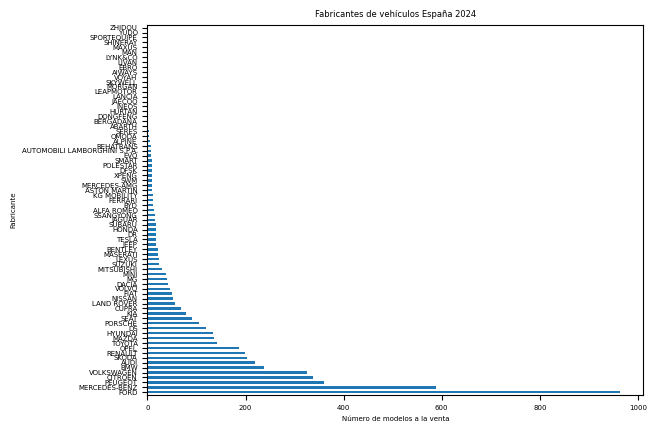

In [17]:
fig = plt.figure()
manager = plt.get_current_fig_manager()
manager.full_screen_toggle()  # activa pantalla completa

count_classes = df_filtrado.value_counts(df_filtrado['Mk'], sort = True)
count_classes.plot(kind = 'barh')
plt.title("Fabricantes de vehículos España 2024")
plt.xlabel("Número de modelos a la venta")
plt.ylabel("Fabricante")
plt.show()

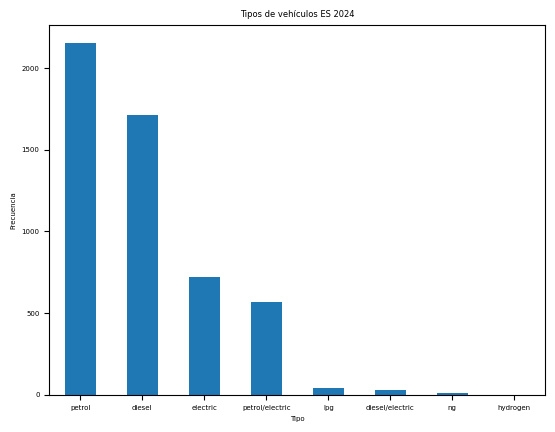

In [18]:
count_classes = df_filtrado['Ft'].value_counts(sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Tipos de vehículos ES 2024")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia");

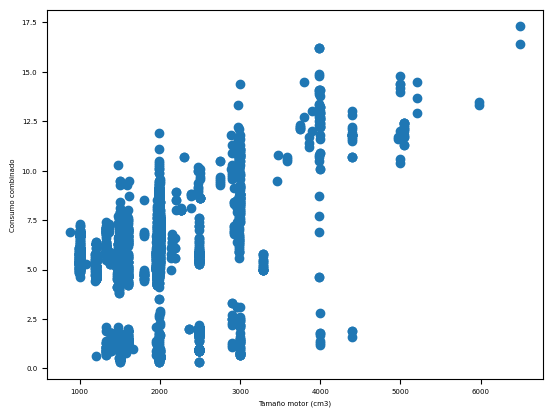

In [19]:
plt.scatter(df_filtrado['ec (cm3)'], 
            df_filtrado['Fuel consumption '])

plt.xlabel('Tamaño motor (cm3)')
plt.ylabel('Consumo combinado')
plt.show()

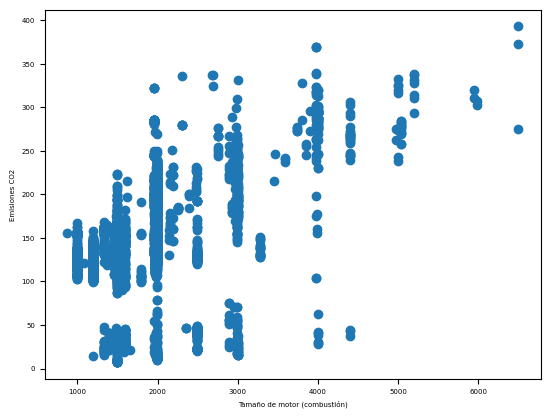

In [20]:
plt.scatter(df_filtrado['ec (cm3)'], 
            df_filtrado['Ewltp (g/km)'])

plt.xlabel('Tamaño de motor (combustión)')
plt.ylabel('Emisiones CO2')
plt.show()

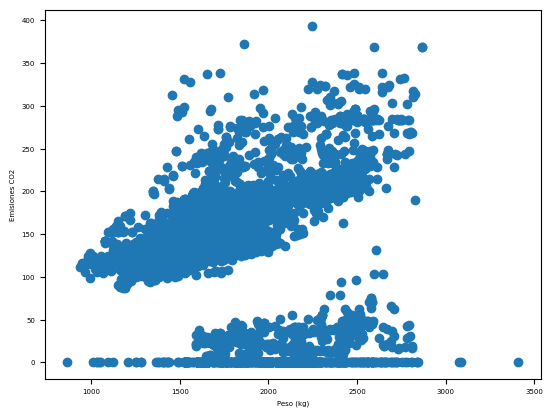

In [21]:
plt.scatter(df_filtrado['m (kg)'], 
            df_filtrado['Ewltp (g/km)'])

plt.xlabel('Peso (kg)')
plt.ylabel('Emisiones CO2')
plt.show()



## 3. Guardamos los dataframes

Propósito:

- Guardar (serializar) los objetos con sus transformaciones para uso directo en siguientes notebooks



In [22]:
df_filtrado.to_pickle("datos_vehiculos_ES_2024.pkl")